In [ ]:
### import libraries
import earthpy ### manage local data
import pandas as pd # Pandas facilitates working with tabular data

# Libraries for visualization
import holoviews as hv 
import hvplot.pandas
import hvplot

In [ ]:
### make URL for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TMAX&stations'
            '=USW00094789&startDate=1950-01-01&endDate=2026-09-23')

ncei_url


'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TMAX&stations=USW00094789&startDate=1950-01-01&endDate=2026-09-23'

In [26]:
### Bring in data with URL
nyc_temp_df = pd.read_csv(
    ncei_url,
    index_col= 'DATE',
    parse_dates= True,
    na_values= ['NaN']
)
nyc_temp_df

,STATION,TMAX
DATE,,
1950-01-01,USW00094789,50.0
1950-01-02,USW00094789,94.0
1950-01-03,USW00094789,106.0
1950-01-04,USW00094789,167.0
1950-01-05,USW00094789,167.0
...,...,...
2026-09-18,USW00094789,283.0
2026-09-19,USW00094789,211.0
2026-09-20,USW00094789,222.0


In [27]:
### Correct temperature column from tenths of a degree Celsius
nyc_temp_df['TMAX'] = nyc_temp_df['TMAX']/10

nyc_temp_df

,STATION,TMAX
DATE,,
1950-01-01,USW00094789,5.0
1950-01-02,USW00094789,9.4
1950-01-03,USW00094789,10.6
1950-01-04,USW00094789,16.7
1950-01-05,USW00094789,16.7
...,...,...
2026-09-18,USW00094789,28.3
2026-09-19,USW00094789,21.1
2026-09-20,USW00094789,22.2


<Axes: ylabel='Frequency'>

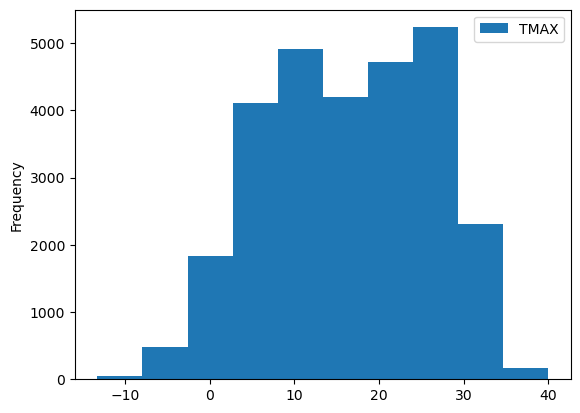

In [31]:
### check for normality
nyc_temp_df.plot.hist()

In [32]:
## Get info about the data
nyc_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28024 entries, 1950-01-01 to 2026-09-22
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  28024 non-null  object 
 1   TMAX     28022 non-null  float64
dtypes: float64(1), object(1)
memory usage: 656.8+ KB


In [33]:
### How many NAs?
single_column_nans = nyc_temp_df['TMAX'].isna().sum()
print(f"NaNs in column: {single_column_nans}")

NaNs in column: 2


In [34]:
### Save the data set 
nyc_temp_df.to_csv('nyc_temp_data.csv')

In [35]:
###  Subset observed temperature only
nyc_temp_df_tmax = nyc_temp_df[['TMAX']]
nyc_temp_df_tmax

,TMAX
DATE,
1950-01-01,5.0
1950-01-02,9.4
1950-01-03,10.6
1950-01-04,16.7
1950-01-05,16.7
...,...
2026-09-18,28.3
2026-09-19,21.1
2026-09-20,22.2


<Axes: title={'center': ' Daily temperature trends in New York City 1948- 2026'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

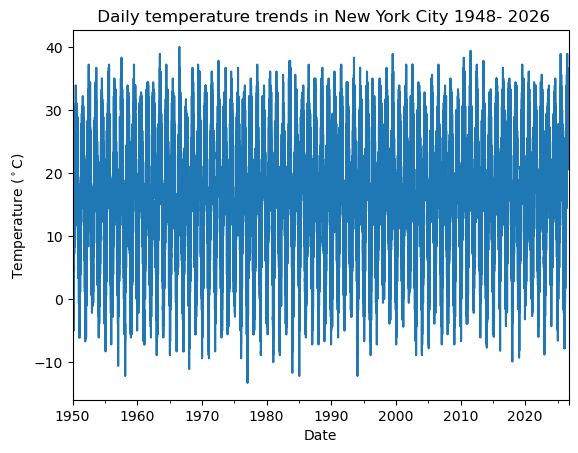

In [36]:
### plot the data using .plot
nyc_temp_df_tmax.plot(legend=False,
    y = 'TMAX',
    title = ' Daily temperature trends in New York City 1948- 2026',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)')

In [37]:
### resample the data to get mean annual temperature
nyc_ann_temp_df = (

### resample the dataframe
    nyc_temp_df_tmax
    .resample('YS')
    .mean()
)

nyc_ann_temp_df

,TMAX
DATE,
1950-01-01,15.544658
1951-01-01,15.786575
1952-01-01,16.104645
1953-01-01,16.723014
1954-01-01,15.841918
...,...
2022-01-01,17.369041
2023-01-01,17.596164
2024-01-01,18.084426


<Axes: title={'center': ' Daily temperature trends in New York City 1950 - 2026'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

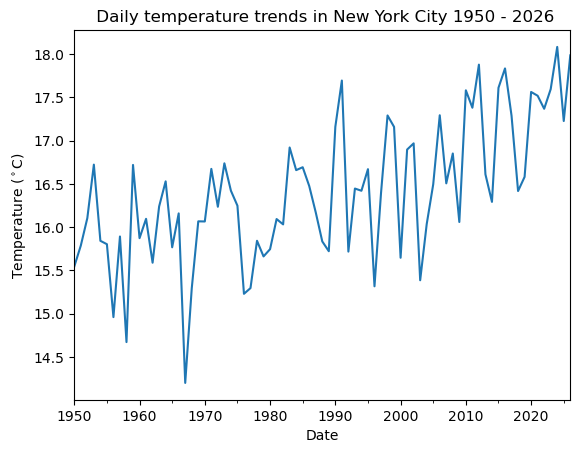

In [38]:
### Plot resampled data 
nyc_ann_temp_df.plot(legend=False,
    y = 'TMAX',
    title = ' Daily temperature trends in New York City 1950 - 2026',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)')

In [ ]:
### Plot resampled data as interactive plot
nyc_ann_temp_df.hvplot(legend=False,
    y = 'TMAX',
    title = ' Daily temperature trends in New York City 1950-2026',
    xlabel = 'Year',
    ylabel = 'Temperature (Degrees Celcius)', 
    ### The formula for the degree wasn't working 
    ### even though I copied it exactly from the other notebook
    color = "red")

:Curve   [DATE]   (TMAX)

In [40]:
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [41]:
### index shows date time index, year Extracts just the year from the date, Values makes it an array, 
### reshape Makes it into a single column, -1 Tells it to estimate how many rows, 1 Means one column
nyc_ann_temp_df.index.year.values.reshape(-1, 1) 

array([[1950],
       [1951],
       [1952],
       [1953],
       [1954],
       [1955],
       [1956],
       [1957],
       [1958],
       [1959],
       [1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [20

In [ ]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = nyc_ann_temp_df.index.year.values.reshape(-1, 1)


### Subset temperature 
dep_variable = nyc_ann_temp_df[['TMAX']]

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.02345352] degrees per year


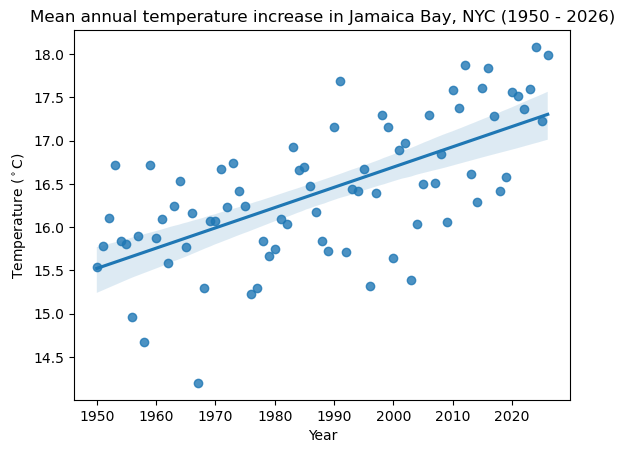

In [ ]:
### plot data
ax = sns.regplot(
    x = nyc_ann_temp_df.index.year, 
    y = nyc_ann_temp_df.TMAX,

## Color of data points
    #color = "blue",

    ## Color of trend line
    #line_kws= {'color': 'blue'}
)

### make labels
ax.set(
    ### Changed title to Jamaica Bay Because that is where the station is
    title = 'Mean annual temperature increase in Jamaica Bay, NYC (1950 - 2026)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)
### save your plot
plt.savefig('/workspaces/01-climate-fall-template/nyc_temp_trend.jpeg')

### plot it
plt.show()